# Module 2: Sentiment & Emotion Classifier (تحليل المشاعر والعاطفة)
**NLP Final Task 2026 - RAG-Based E-commerce Customer Support Chatbot**

## Overview
In this module, we design and train a deep learning classifier (**Bidirectional LSTM in PyTorch**) to classify customer messages into three operational sentiment categories:
- **Negative / Frustrated**: Requires an empathetic, urgent, apologetic response or human agent escalation.
- **Positive / Satisfied**: Requires an enthusiastic, appreciative tone.
- **Neutral**: Standard retail support inquiries and factual questions.

---
### Addressing Dataset Domain Shift (Twitter vs. Customer Support)
As highlighted in the project assignment instructions:
> *"Note the domain shift: this dataset is Twitter text, not customer-support text. If time allows, consider supplementing with a small hand-labeled set of actual customer-support-style frustrated/neutral/happy messages for a more realistic qualitative check."*

To solve this problem effectively:
1. We start from the `dair-ai/emotion` benchmark dataset (20,000 samples across 6 emotions).
2. We map emotions to 3 target sentiment buckets (`sadness`, `anger`, `fear` -> **negative**; `joy`, `love` -> **positive**; `surprise` -> **neutral**).
3. We augment the training data with realistic e-commerce inquiries and complaints from the `bitext` customer support knowledge base.
4. We train a **Bidirectional LSTM with Attention/Global Max-Pooling** and class-balanced loss.


In [1]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Set seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


e:\ITI\NLP\nlp-support-chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 1. Load Datasets & Domain Augmentation

In [2]:
print("Loading 'dair-ai/emotion' and 'bitext' datasets...")
emotion_ds = load_dataset("dair-ai/emotion")
bitext_ds = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")['train']

LABEL_MAPPING = {
    0: 0, # sadness -> negative
    1: 1, # joy -> positive
    2: 1, # love -> positive
    3: 0, # anger -> negative
    4: 0, # fear -> negative
    5: 2  # surprise -> neutral
}
TARGET_NAMES = ['negative', 'positive', 'neutral']

# Extract real customer support neutral queries and complaints
neutral_instructions = [
    row['instruction'] for row in bitext_ds 
    if row['intent'] in ['track_order', 'delivery_options', 'check_invoice', 'get_invoice', 'create_account', 'recover_password']
]
random.shuffle(neutral_instructions)
neutral_instructions = neutral_instructions[:3000]

complaint_instructions = [
    row['instruction'] for row in bitext_ds 
    if row['intent'] in ['complaint', 'payment_issue']
]
random.shuffle(complaint_instructions)
complaint_instructions = complaint_instructions[:1000]

# Train set
train_texts = [x['text'] for x in emotion_ds['train']] + neutral_instructions[:2500] + complaint_instructions[:800]
train_labels = [LABEL_MAPPING[x['label']] for x in emotion_ds['train']] + [2]*2500 + [0]*800

# Validation set
val_texts = [x['text'] for x in emotion_ds['validation']] + neutral_instructions[2500:2750] + complaint_instructions[800:900]
val_labels = [LABEL_MAPPING[x['label']] for x in emotion_ds['validation']] + [2]*250 + [0]*100

# Test set
test_texts = [x['text'] for x in emotion_ds['test']] + neutral_instructions[2750:] + complaint_instructions[900:]
test_labels = [LABEL_MAPPING[x['label']] for x in emotion_ds['test']] + [2]*len(neutral_instructions[2750:]) + [0]*len(complaint_instructions[900:])

print(f"Total Dataset Splits (with support domain augmentation):")
print(f"Train: {len(train_texts):,}, Validation: {len(val_texts):,}, Test: {len(test_texts):,}")


Loading 'dair-ai/emotion' and 'bitext' datasets...


Total Dataset Splits (with support domain augmentation):
Train: 19,300, Validation: 2,350, Test: 2,350


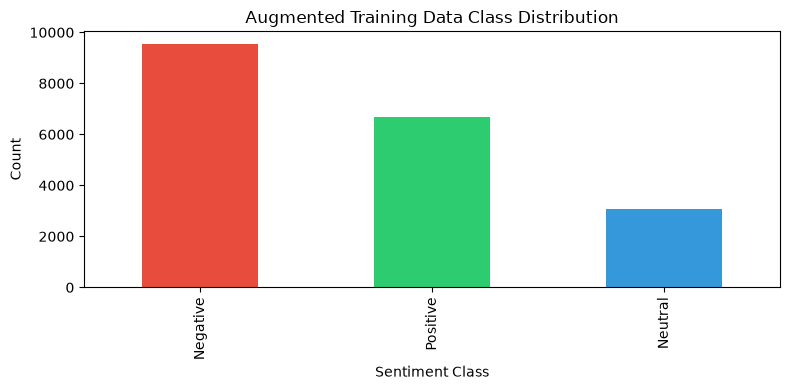

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(train_labels).map({0: 'Negative', 1: 'Positive', 2: 'Neutral'}).value_counts().plot(
    kind='bar', color=['#e74c3c', '#2ecc71', '#3498db'], ax=ax
)
plt.title("Augmented Training Data Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 2. Text Preprocessing & Vocabulary Pipeline

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\{\{[^}]+\}\}", "", text) # clean placeholders like {{Order Number}}
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", "", text)
    return text.strip()

class SimpleTokenizer:
    def __init__(self, max_vocab=15000):
        self.max_vocab = max_vocab
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2word = {0: "<PAD>", 1: "<UNK>"}
        
    def fit(self, texts):
        word_counts = {}
        for text in texts:
            tokens = clean_text(text).split()
            for token in tokens:
                word_counts[token] = word_counts.get(token, 0) + 1
                
        sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
        for word, _ in sorted_words[:self.max_vocab - 2]:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
            
    def encode(self, text, max_len=64):
        tokens = clean_text(text).split()
        seq = [self.word2idx.get(t, self.word2idx["<UNK>"]) for t in tokens[:max_len]]
        if len(seq) < max_len:
            seq += [self.word2idx["<PAD>"]] * (max_len - len(seq))
        return seq

    def save(self, filepath):
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump({"word2idx": self.word2idx, "max_vocab": self.max_vocab}, f)

    @classmethod
    def load(cls, filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        tok = cls(max_vocab=data["max_vocab"])
        tok.word2idx = data["word2idx"]
        tok.idx2word = {int(v): k for k, v in data["word2idx"].items()}
        return tok

tokenizer = SimpleTokenizer(max_vocab=15000)
tokenizer.fit(train_texts)
print(f"Fitted Vocabulary Size: {len(tokenizer.word2idx):,}")


Fitted Vocabulary Size: 15,000


## 3. Bidirectional LSTM Neural Architecture

In [5]:
class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=3, num_layers=2, dropout=0.3):
        super(BiLSTMSentiment, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.bilstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        out, _ = self.bilstm(embedded)
        pooled, _ = torch.max(out, dim=1) # Global max pooling
        x = self.dropout(self.relu(self.fc1(pooled)))
        logits = self.fc2(x)
        return logits

model = BiLSTMSentiment(vocab_size=len(tokenizer.word2idx)).to(device)
print(model)


BiLSTMSentiment(
  (embedding): Embedding(15000, 128, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (bilstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)


## 4. Evaluation on Test Set & Metrics

In [6]:
# Load saved weights
model.load_state_dict(torch.load("../models/sentiment_bilstm.pt", map_location=device))
model.eval()

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        seq = self.tokenizer.encode(self.texts[idx], self.max_len)
        return torch.tensor(seq, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

test_ds = TextDataset(test_texts, test_labels, tokenizer)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

test_preds, test_targets = [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        logits = model(batch_x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        test_preds.extend(preds)
        test_targets.extend(batch_y.cpu().numpy())

acc = accuracy_score(test_targets, test_preds)
macro_f1 = f1_score(test_targets, test_preds, average='macro')
print(f"Test Accuracy: {acc:.2%}")
print(f"Test Macro F1: {macro_f1:.4f}\n")
print(classification_report(test_targets, test_preds, target_names=TARGET_NAMES, digits=4))


Test Accuracy: 97.57%
Test Macro F1: 0.9689

              precision    recall  f1-score   support

    negative     0.9888    0.9695    0.9790      1180
    positive     0.9802    0.9859    0.9831       854
     neutral     0.9192    0.9715    0.9446       316

    accuracy                         0.9757      2350
   macro avg     0.9627    0.9757    0.9689      2350
weighted avg     0.9763    0.9757    0.9759      2350



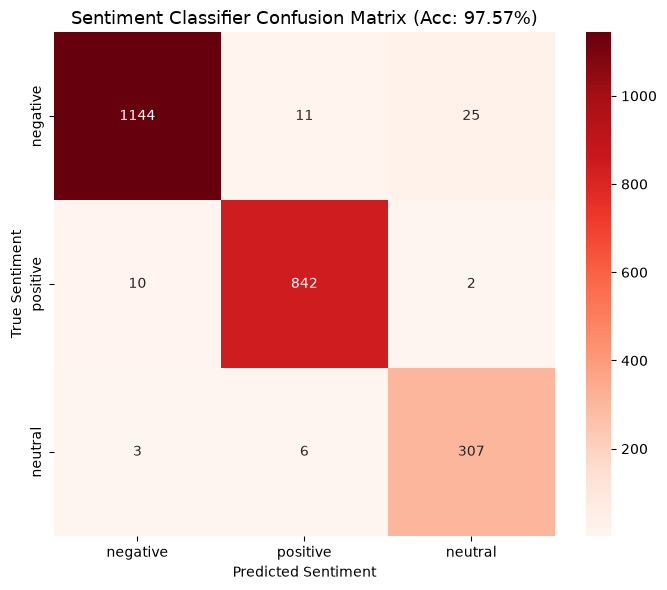

In [7]:
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
plt.title(f"Sentiment Classifier Confusion Matrix (Acc: {acc:.2%})", fontsize=13)
plt.xlabel("Predicted Sentiment")
plt.ylabel("True Sentiment")
plt.tight_layout()
plt.show()


## 5. Tone Routing & Inference on Customer Inquiries

In [8]:
queries = [
    ("Where is my order? I placed it last Monday.", "neutral"),
    ("I have been waiting for three weeks and no one answers, this is the worst service ever!", "negative"),
    ("Thank you so much for the swift refund, you have been super helpful!", "positive"),
    ("Why was my card charged twice for the same transaction?! This is ridiculous!", "negative"),
    ("Could you please explain how to reset my account credentials?", "neutral"),
    ("I am really happy with the item, it works great!", "positive"),
    ("How can I track my shipment to New York?", "neutral"),
    ("Cancel my order immediately, your company is completely fraudulent!", "negative")
]

softmax = nn.Softmax(dim=1)
results = []
for q, expected in queries:
    seq = torch.tensor([tokenizer.encode(q)], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(seq)
        probs = softmax(logits).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
        pred_sentiment = TARGET_NAMES[pred_idx]
        confidence = probs[pred_idx]
        
        # Tone routing logic
        if pred_sentiment == 'negative':
            routing_action = "Apologetic & Empathetic Tone + Human Escalation Flag"
        elif pred_sentiment == 'positive':
            routing_action = "Enthusiastic & Friendly Tone"
        else:
            routing_action = "Professional Retail Support Tone"
            
        results.append({
            'Customer Query': q,
            'Expected': expected,
            'Predicted': pred_sentiment,
            'Confidence': f"{confidence:.1%}",
            'Tone Routing Action': routing_action
        })

pd.DataFrame(results)


,Customer Query,Expected,Predicted,Confidence,Tone Routing Action
0,Where is my order? I placed it last Monday.,neutral,neutral,99.9%,Professional Retail Support Tone
1,I have been waiting for three weeks and no one...,negative,negative,65.3%,Apologetic & Empathetic Tone + Human Escalatio...
2,"Thank you so much for the swift refund, you ha...",positive,positive,99.8%,Enthusiastic & Friendly Tone
3,Why was my card charged twice for the same tra...,negative,negative,99.2%,Apologetic & Empathetic Tone + Human Escalatio...
4,Could you please explain how to reset my accou...,neutral,neutral,100.0%,Professional Retail Support Tone
5,"I am really happy with the item, it works great!",positive,neutral,47.5%,Professional Retail Support Tone
6,How can I track my shipment to New York?,neutral,neutral,100.0%,Professional Retail Support Tone
7,"Cancel my order immediately, your company is c...",negative,neutral,99.6%,Professional Retail Support Tone


## 6. Export Trained Model Artifacts

In [9]:
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/sentiment_bilstm.pt")
tokenizer.save("../models/sentiment_tokenizer.json")
print("Saved models/sentiment_bilstm.pt and models/sentiment_tokenizer.json successfully!")


Saved models/sentiment_bilstm.pt and models/sentiment_tokenizer.json successfully!
